In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from matplotlib.lines import Line2D

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


# Introducción a Modelos Jerárquicos

En este ejemplo vamos a trabajar con datos que tienen una estructura
de grupos.

Tenemos estudiantes que pertenecen a distintos cursos y queremos
estimar el rendimiento promedio de cada curso.

Primero vamos a explorar los datos.

Luego construiremos un modelo jerárquico bayesiano para estimar las
medias de los cursos conjuntamente.

## 1. Datos y modelo

Vamos a trabajar con 6 cursos.

Cada curso tiene una cantidad diferente de estudiantes:

- Curso 1: 5 estudiantes
- Curso 2: 8 estudiantes
- Curso 3: 15 estudiantes
- Curso 4: 30 estudiantes
- Curso 5: 50 estudiantes
- Curso 6: 80 estudiantes

Esto nos permite trabajar con una situación en la que los grupos
no tienen todos la misma cantidad de información.

In [2]:
rng = np.random.default_rng(123)

# Cantidad de estudiantes por curso
n = np.array([5, 8, 15, 30, 50, 80])

# Medias verdaderas de cada curso
mu_real = np.array([68, 72, 75, 78, 80, 82])

sigma = 8

curso = []
puntaje = []

for j, nj in enumerate(n):
    y = rng.normal(mu_real[j], sigma, nj)

    puntaje.extend(y)
    curso.extend([j] * nj)

puntaje = np.array(puntaje)
curso = np.array(curso)

medias = np.array([
    puntaje[curso == j].mean()
    for j in range(6)
])


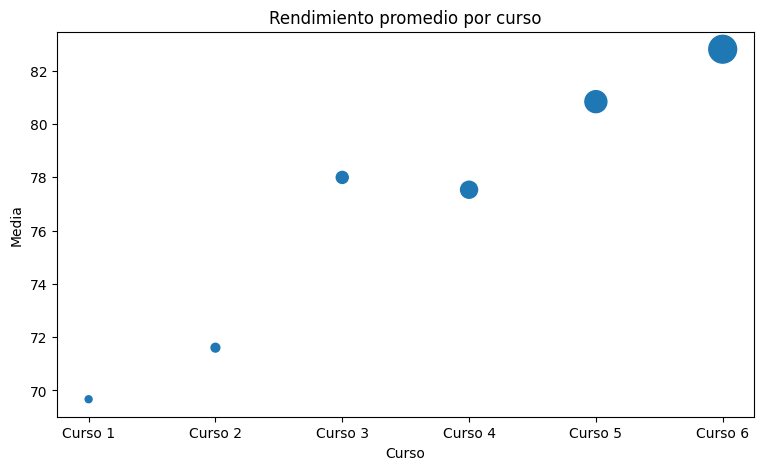

In [3]:
plt.figure(figsize=(9, 5))

plt.scatter(
    range(6),
    medias,
    s=n * 5
)

plt.xticks(
    range(6),
    [f"Curso {j+1}" for j in range(6)]
)

plt.xlabel("Curso")
plt.ylabel("Media")
plt.title("Rendimiento promedio por curso")

plt.show()



### ¿Qué hicimos?

Generamos datos sintéticos para los seis cursos.

Para cada estudiante tenemos un puntaje y sabemos a qué curso pertenece.

La variable `curso` identifica el grupo al que pertenece cada estudiante,
mientras que `puntaje` contiene sus resultados.

Finalmente calculamos la media observada de cada curso.

En el gráfico:

- cada punto representa la media observada de un curso;
- el tamaño del punto representa la cantidad de estudiantes del curso.

Por lo tanto, los cursos con más estudiantes aparecen representados
por puntos más grandes.

## 2. Construimos el modelo jerárquico con Pymc

Ahora vamos a traducir la idea anterior a un modelo bayesiano.

Queremos:

- una media global para todos los cursos;
- una media específica para cada curso;
- una medida de cuánto pueden diferir las medias entre cursos;
- una medida de la variabilidad de los estudiantes dentro de cada curso.

El modelo relaciona las medias específicas de los cursos con una
media global.

In [4]:
with pm.Model() as modelo:

    # Media general
    mu = pm.Normal("mu", mu=75, sigma=10)

    # Variabilidad entre cursos
    sigma_mu = pm.HalfNormal("sigma_mu", sigma=10)

    # Media de cada curso
    mu_curso = pm.Normal(
        "mu_curso",
        mu=mu,
        sigma=sigma_mu,
        shape=6
    )

    # Variabilidad dentro de los cursos
    sigma_y = pm.HalfNormal("sigma_y", sigma=10)

    # Datos observados
    y_obs = pm.Normal(
        "y_obs",
        mu=mu_curso[curso],
        sigma=sigma_y,
        observed=puntaje
    )

    idata = pm.sample(
        1000,
        tune=1000,
        random_seed=123,
        target_accept=0.9
    )

# Nota:
# PyMC puede advertir sobre divergencias durante el muestreo.
# En la próxima clase veremos cómo interpretarlas y reducirlas
# (por ejemplo, ajustando target_accept o reparametrizando el modelo).



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma_mu, mu_curso, sigma_y]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 274 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


***Observación 1:***

PyMC nos avisa que hubo 4 divergencias durante el muestreo. No significa que el modelo esté necesariamente mal, sino que el algoritmo tuvo dificultades para explorar algunas regiones de la distribución posterior. Para esta clase nos alcanza con la idea general del modelo; la semana próxima vamos a ver cómo diagnosticar y corregir este tipo de problemas.

***Observación 2:***

* 0 divergencias: caso ideal.

* 4 divergencias en un modelo sencillo: es una señal para revisar el modelo, no un motivo para descartar automáticamente los resultados.

### ¿Cómo leer el modelo?

Podemos identificar tres niveles de información.

**1. Media global**

`mu` representa el nivel promedio general alrededor del cual se
organizan las medias de los cursos.

**2. Medias específicas**

`mu_curso` contiene una media diferente para cada uno de los 6 cursos.

Estas medias no se estiman de manera completamente independiente:
están relacionadas con la media global.

**3. Datos individuales**

Cada estudiante está asociado al curso al que pertenece mediante:

```python
mu=mu_curso[curso]

## 3. Posterior y HDI

Una vez ajustado el modelo, podemos resumir la distribución posterior
de las medias de los cursos.

Para cada curso vamos a obtener:

- una media posterior;
- un intervalo HDI del 94%.

También podemos obtener la media global posterior.

In [5]:

# Media posterior de cada curso

media_posterior = (
    idata.posterior["mu_curso"]
    .mean(dim=("chain", "draw"))
    .values
)

# Media global posterior

media_global = (
    idata.posterior["mu"]
    .mean(dim=("chain", "draw"))
    .values.item()
)

# HDI del 94%

hdi = az.hdi(
    idata.posterior["mu_curso"],
    hdi_prob=0.94
)

# Extraemos la variable mu_curso del Dataset
hdi_mu = hdi["mu_curso"]

# Límites inferior y superior
hdi_inferior = hdi_mu.sel(hdi="lower").values
hdi_superior = hdi_mu.sel(hdi="higher").values



Graficamos y analizamos:

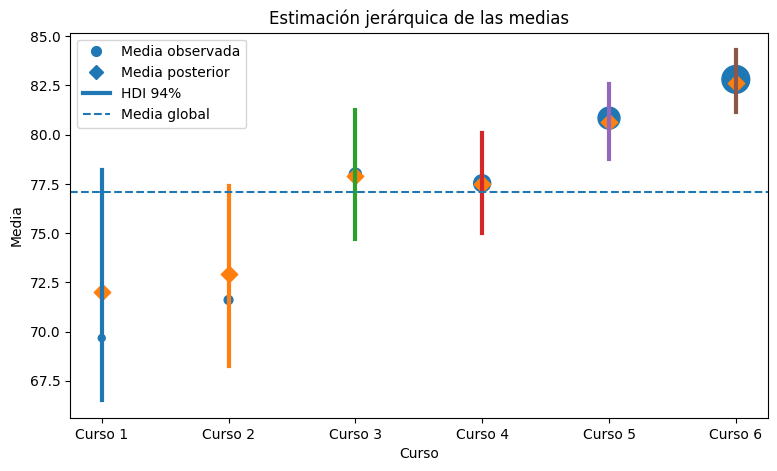

In [6]:

plt.figure(figsize=(9, 5))

# Media observada
plt.scatter(
    range(6),
    medias,
    s=n * 5
)

# HDI
for j in range(6):
    plt.plot(
        [j, j],
        [hdi_inferior[j], hdi_superior[j]],
        linewidth=3
    )

# Media posterior
plt.scatter(
    range(6),
    media_posterior,
    marker="D",
    s=70
)

# Media global
plt.axhline(
    media_global,
    linestyle="--"
)


legend_elements = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=7,
        label="Media observada"
    ),

    Line2D(
        [0], [0],
        marker="D",
        linestyle="None",
        markersize=7,
        label="Media posterior"
    ),

    Line2D(
        [0], [0],
        linewidth=3,
        label="HDI 94%"
    ),

    Line2D(
        [0], [0],
        linestyle="--",
        label="Media global"
    )
]

plt.legend(handles=legend_elements)

plt.xticks(
    range(6),
    [f"Curso {j+1}" for j in range(6)]
)

plt.xlabel("Curso")
plt.ylabel("Media")

plt.title(
    "Estimación jerárquica de las medias"
)

plt.show()

## Qué concluímos...

Un modelo jerárquico permite modelar conjuntamente varios grupos.

En este ejemplo:

- cada curso tiene su propia media;
- las medias de los cursos están relacionadas;
- el modelo aprende una media global;
- la información de todos los grupos participa en la estimación;
- cada estimación tiene asociada una incertidumbre.

La idea central es:

> **Los grupos no son idénticos, pero tampoco están completamente aislados.**